In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all anomaly files (they contain all features + anomaly flags)
tickers = ['BHARTIARTL', 'HDFCBANK', 'HINDUNILVR', 'ICICIBANK',
           'INFY', 'RELIANCE', 'TCS', 'TMPV']

all_data = {}
for ticker in tickers:
    df = pd.read_csv(f'../data/anomalies/{ticker}_anomalies.csv',
                     index_col=0, parse_dates=True)
    all_data[ticker] = df

# Build a combined daily returns dataframe
returns = pd.DataFrame({ticker: all_data[ticker]['daily_return'] 
                        for ticker in tickers})

print(returns.shape)
print(returns.head())

(1814, 8)
            BHARTIARTL  HDFCBANK  HINDUNILVR  ICICIBANK      INFY  RELIANCE  \
Date                                                                          
2019-02-12   -0.003043 -0.004650   -0.005707  -0.016426 -0.016190  0.002514   
2019-02-14   -0.033574 -0.009156   -0.005266  -0.001016 -0.013859 -0.025629   
2019-02-15    0.012633 -0.004526   -0.006863  -0.005233  0.002568  0.016541   
2019-02-18   -0.006730 -0.005117   -0.011789  -0.009937 -0.001213 -0.019567   
2019-02-19    0.003801 -0.002799   -0.007963   0.013284 -0.022603 -0.003278   

                 TCS      TMPV  
Date                            
2019-02-12 -0.006922 -0.005568  
2019-02-14 -0.003412  0.053030  
2019-02-15 -0.007288  0.011260  
2019-02-18 -0.029266  0.007733  
2019-02-19 -0.033243  0.005218  


In [2]:
# Assume equal weight portfolio (12.5% in each of 8 stocks)
weights = np.array([1/8] * 8)

# Individual stock annualized volatility (multiply daily std by sqrt(252))
# 252 = trading days in a year
individual_vol = returns.std() * np.sqrt(252)
print("Annualized Volatility per Stock:")
print(individual_vol.sort_values(ascending=False).round(4))

# Portfolio variance using weights and covariance matrix
cov_matrix = returns.cov() * 252  # annualized covariance
portfolio_variance = weights.T @ cov_matrix.values @ weights
portfolio_vol = np.sqrt(portfolio_variance)

# Weighted average of individual volatilities (what it would be with NO diversification)
weighted_avg_vol = np.sum(weights * individual_vol.values)

print(f"\nPortfolio Volatility (actual, with diversification): {portfolio_vol:.4f} ({portfolio_vol*100:.2f}%)")
print(f"Weighted Average Individual Vol (no diversification): {weighted_avg_vol:.4f} ({weighted_avg_vol*100:.2f}%)")
print(f"Diversification Benefit: {(weighted_avg_vol - portfolio_vol)*100:.2f}% reduction in volatility")

Annualized Volatility per Stock:
TMPV          0.4536
ICICIBANK     0.2920
BHARTIARTL    0.2816
RELIANCE      0.2787
INFY          0.2787
HDFCBANK      0.2514
TCS           0.2423
HINDUNILVR    0.2270
dtype: float64

Portfolio Volatility (actual, with diversification): 0.1833 (18.33%)
Weighted Average Individual Vol (no diversification): 0.2882 (28.82%)
Diversification Benefit: 10.48% reduction in volatility


Portfolio Daily VaR (95% confidence): -1.51%
Portfolio Daily VaR (99% confidence): -3.09%

In plain English:
On 95% of days, you won't lose more than 1.51% of your portfolio value
On 99% of days, you won't lose more than 3.09% of your portfolio value


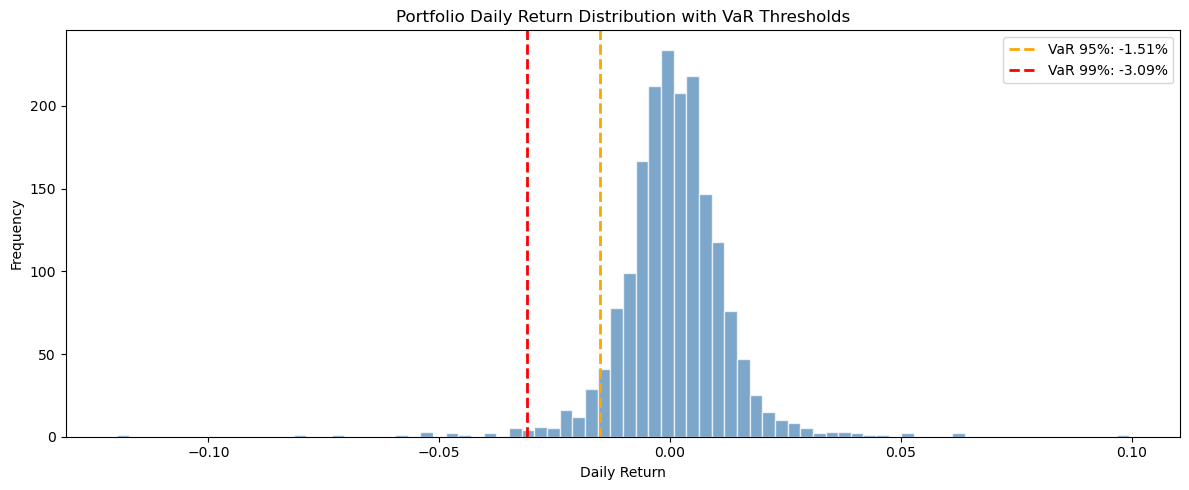

In [3]:
# Historical VaR - what's the worst daily loss at 95% and 99% confidence?
portfolio_daily_returns = returns.mean(axis=1)  # equal weight daily portfolio return

var_95 = np.percentile(portfolio_daily_returns, 5)
var_99 = np.percentile(portfolio_daily_returns, 1)

print(f"Portfolio Daily VaR (95% confidence): {var_95*100:.2f}%")
print(f"Portfolio Daily VaR (99% confidence): {var_99*100:.2f}%")
print(f"\nIn plain English:")
print(f"On 95% of days, you won't lose more than {abs(var_95)*100:.2f}% of your portfolio value")
print(f"On 99% of days, you won't lose more than {abs(var_99)*100:.2f}% of your portfolio value")

# Visualize return distribution with VaR lines
plt.figure(figsize=(12, 5))
plt.hist(portfolio_daily_returns, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95*100:.2f}%')
plt.axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'VaR 99%: {var_99*100:.2f}%')
plt.title('Portfolio Daily Return Distribution with VaR Thresholds')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Combine all risk metrics into one clean summary table
risk_summary = pd.DataFrame({
    'Annualized_Vol': individual_vol,
    'Anomaly_Count': [len(pd.read_csv(f'../data/anomalies/{t}_anomalies.csv', 
                      index_col=0)[lambda x: x['is_anomaly']==1]) for t in tickers],
    'Mean_Daily_Return': returns.mean(),
    'Sharpe_Proxy': (returns.mean() * 252) / individual_vol  # simplified Sharpe ratio
})

risk_summary = risk_summary.sort_values('Annualized_Vol', ascending=False).round(4)
print("Portfolio Risk Summary:")
print(risk_summary.to_string())

Portfolio Risk Summary:
            Annualized_Vol  Anomaly_Count  Mean_Daily_Return  Sharpe_Proxy
TMPV                0.4536             37             0.0009        0.5027
ICICIBANK           0.2920             37             0.0009        0.8014
BHARTIARTL          0.2816             37             0.0012        1.0895
RELIANCE            0.2787             37             0.0006        0.5757
INFY                0.2787             37             0.0005        0.4475
HDFCBANK            0.2514             37             0.0004        0.3740
TCS                 0.2423             37             0.0003        0.2756
HINDUNILVR          0.2270             37             0.0003        0.3026


In [5]:
import os
os.makedirs('../data/portfolio', exist_ok=True)

# Save risk summary
risk_summary.to_csv('../data/portfolio/risk_summary.csv')

# Save portfolio metrics
portfolio_metrics = {
    'portfolio_volatility': round(portfolio_vol, 4),
    'weighted_avg_vol': round(weighted_avg_vol, 4),
    'diversification_benefit': round(weighted_avg_vol - portfolio_vol, 4),
    'var_95': round(var_95, 4),
    'var_99': round(var_99, 4),
    'portfolio_mean_daily_return': round(portfolio_daily_returns.mean(), 6)
}

pd.Series(portfolio_metrics).to_csv('../data/portfolio/portfolio_metrics.csv')
print("Saved successfully")
print(pd.Series(portfolio_metrics))

Saved successfully
portfolio_volatility           0.183300
weighted_avg_vol               0.288200
diversification_benefit        0.104800
var_95                        -0.015100
var_99                        -0.030900
portfolio_mean_daily_return    0.000637
dtype: float64


In [6]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
streamlit --version

NameError: name 'streamlit' is not defined